In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from transformers import XLMRobertaTokenizer, XLMRobertaForSequenceClassification
from preprocessing import TextPreprocessor
from datasets import Dataset

s:\Diploma Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Налаштування

In [2]:
plt.rcParams.update({
    "figure.facecolor": "#1e1e2e",
    "axes.facecolor":   "#2a2a3e",
    "axes.edgecolor":   "#3a3a5a",
    "axes.labelcolor":  "#e0e0f0",
    "xtick.color":      "#8888aa",
    "ytick.color":      "#8888aa",
    "text.color":       "#e0e0f0",
    "grid.color":       "#3a3a5a",
    "grid.alpha":       0.5,
})

In [3]:
PURPLE = "#7c6af7"
TEAL   = "#4caf87"
RED    = "#e05c6a"

## Функція для тестування моделі

In [8]:
def evaluate(input_path: str, model_path: str = "xlm_trained_model",
             test_size: float = 0.2, seed: int = 42):

    import torch
    import matplotlib.pyplot as plt
    from datasets import Dataset
    from transformers import XLMRobertaTokenizer, XLMRobertaForSequenceClassification
    from sklearn.metrics import (
        classification_report, accuracy_score, f1_score,
        precision_score, recall_score, confusion_matrix,
        roc_curve, auc
    )

    preprocessor = TextPreprocessor(input_path)
    df = preprocessor.run()
    df = df[["Text", "labels"]]

    dataset = Dataset.from_pandas(df)
    split = dataset.train_test_split(test_size=test_size, seed=seed)
    test_df = split["test"].to_pandas()

    tokenizer = XLMRobertaTokenizer.from_pretrained(model_path)
    model = XLMRobertaForSequenceClassification.from_pretrained(model_path, num_labels=2)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    preds = []
    probs = []

    for text in test_df["Text"]:
        inputs = tokenizer(text, return_tensors="pt", truncation=True,
                           padding=True, max_length=128)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            logits = model(**inputs).logits
            prob = torch.nn.functional.softmax(logits, dim=-1)

        preds.append(logits.argmax(-1).item())
        probs.append(prob[0][1].item())

    labels = test_df["labels"].tolist()

    print(classification_report(labels, preds, target_names=["Правда", "Фейк"]))
    print(f"Accuracy:  {accuracy_score(labels, preds):.4f}")
    print(f"F1:        {f1_score(labels, preds):.4f}")
    print(f"Precision: {precision_score(labels, preds):.4f}")
    print(f"Recall:    {recall_score(labels, preds):.4f}")

    plt.figure(figsize=(6, 6))
    cm = confusion_matrix(labels, preds)

    plt.imshow(cm, cmap="Blues")
    plt.xticks([0, 1], ["Правда", "Фейк"])
    plt.yticks([0, 1], ["Правда", "Фейк"])
    plt.xlabel("Передбачений клас")
    plt.ylabel("Реальний клас")
    plt.title("Confusion Matrix")

    for i in range(2):
        for j in range(2):
            plt.text(j, i, f"{cm[i, j]:,}",
                     ha="center", va="center",
                     fontsize=14, fontweight="bold",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")

    plt.colorbar()
    plt.tight_layout()
    plt.show()
    

    plt.figure(figsize=(6, 6))

    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2.5, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.2, label="Випадковий класифікатор")

    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title("ROC крива")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 6))

    metrics = {
        "Accuracy":  accuracy_score(labels, preds),
        "F1":        f1_score(labels, preds),
        "Precision": precision_score(labels, preds),
        "Recall":    recall_score(labels, preds),
        "AUC":       roc_auc,
    }

    bars = plt.bar(metrics.keys(), metrics.values(), width=0.5)

    for bar, val in zip(bars, metrics.values()):
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f"{val:.4f}",
                 ha="center")

    plt.ylim(0, 1.1)
    plt.title("Підсумкові метрики")
    plt.ylabel("Значення")
    plt.grid(axis="y")

    plt.tight_layout()
    plt.show()

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8184.21it/s]


              precision    recall  f1-score   support

      Правда       0.87      0.81      0.84      1284
        Фейк       0.90      0.93      0.92      2361

    accuracy                           0.89      3645
   macro avg       0.88      0.87      0.88      3645
weighted avg       0.89      0.89      0.89      3645

Accuracy:  0.8889
F1:        0.9157
Precision: 0.9005
Recall:    0.9314


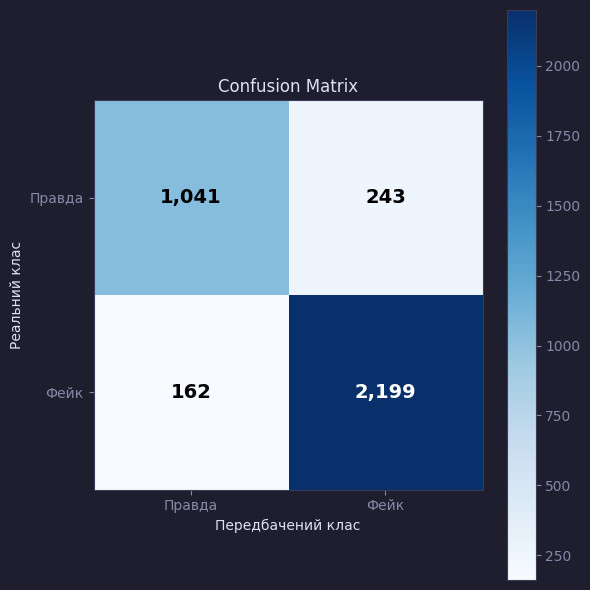

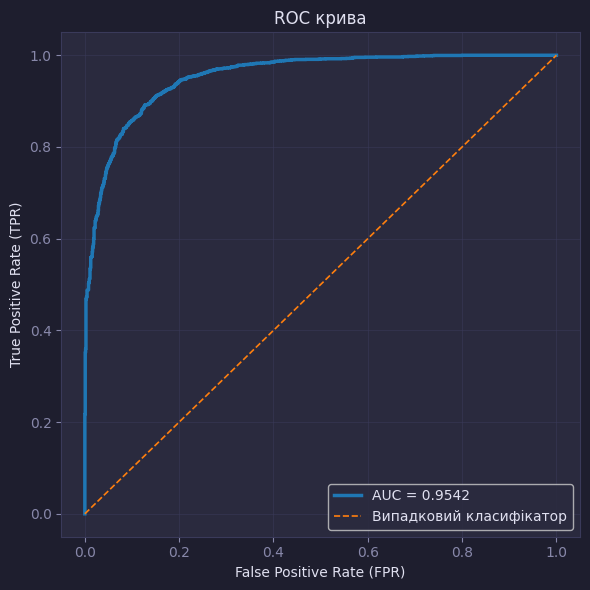

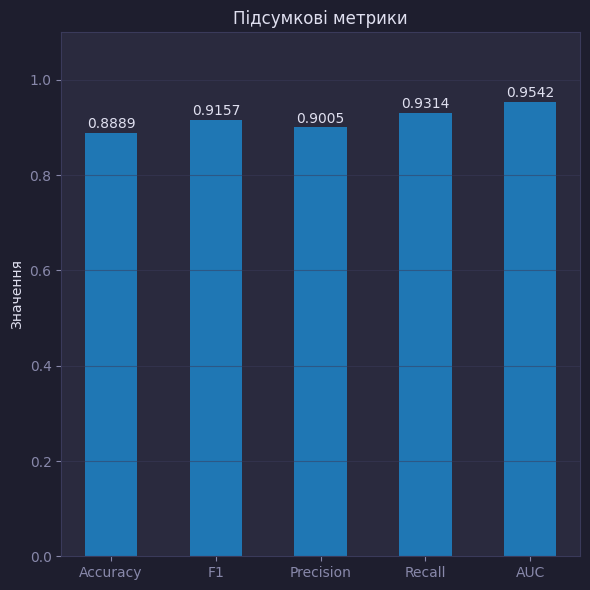

In [9]:
evaluate("model_training/raw_news_train/raw_news.csv")